In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/datasets/train"
TEST_DIR = "/content/drive/MyDrive/datasets/test"

In [ ]:
BATCH_SIZE = 32
EPOCHS = 5
IMAGE_SIZE = (224, 224)

In [ ]:
def train_val_generators(TRAINING_DIR, TEST_DIR):
    train_datagen = ImageDataGenerator(
        rescale=1.0/255.0,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(rescale=1.0/255.0)

    train_generator = train_datagen.flow_from_directory(
        TRAINING_DIR,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        target_size=IMAGE_SIZE
    )

    val_generator = val_datagen.flow_from_directory(
        TEST_DIR,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        target_size=IMAGE_SIZE
    )

    return train_generator, val_generator

In [ ]:
train_generator, test_generator = train_val_generators(TRAIN_DIR, TEST_DIR)
label_map = train_generator.class_indices
num_classes = len(label_map)
print(label_map)

Found 5757 images belonging to 21 classes.
Found 1640 images belonging to 21 classes.
{'Grape__black_measles': 0, 'Grape__black_rot': 1, 'Grape__healthy': 2, 'Grape__leaf_blight_(isariopsis_leaf_spot)': 3, 'Lemon__diseased': 4, 'Lemon__healthy': 5, 'Pomegranate__diseased': 6, 'Pomegranate__healthy': 7, 'guava_Disease Free': 8, 'guava_Phytopthora': 9, 'guava_Red rust': 10, 'guava_Scab': 11, 'guava_Styler and Root': 12, 'mango_Anthracnose': 13, 'mango_Bacterial Canker': 14, 'mango_Cutting Weevil': 15, 'mango_Die Back': 16, 'mango_Gall Midge': 17, 'mango_Healthy': 18, 'mango_Powdery Mildew': 19, 'mango_Sooty Mould': 20}


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/datasets/train"
TEST_DIR = "/content/drive/MyDrive/datasets/test"

In [ ]:
BATCH_SIZE = 32
EPOCHS = 5
IMAGE_SIZE = (224, 224)

In [ ]:
def train_val_generators(TRAINING_DIR, TEST_DIR):
    train_datagen = ImageDataGenerator(
        rescale=1.0/255.0,
        rotation_range=45,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(rescale=1.0/255.0)

    train_generator = train_datagen.flow_from_directory(
        TRAINING_DIR,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        target_size=IMAGE_SIZE
    )

    val_generator = val_datagen.flow_from_directory(
        TEST_DIR,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        target_size=IMAGE_SIZE
    )

    return train_generator, val_generator

In [ ]:
train_generator, test_generator = train_val_generators(TRAIN_DIR, TEST_DIR)
label_map = train_generator.class_indices
num_classes = len(label_map)
print(label_map)

Found 5757 images belonging to 21 classes.
Found 1640 images belonging to 21 classes.
{'Grape__black_measles': 0, 'Grape__black_rot': 1, 'Grape__healthy': 2, 'Grape__leaf_blight_(isariopsis_leaf_spot)': 3, 'Lemon__diseased': 4, 'Lemon__healthy': 5, 'Pomegranate__diseased': 6, 'Pomegranate__healthy': 7, 'guava_Disease Free': 8, 'guava_Phytopthora': 9, 'guava_Red rust': 10, 'guava_Scab': 11, 'guava_Styler and Root': 12, 'mango_Anthracnose': 13, 'mango_Bacterial Canker': 14, 'mango_Cutting Weevil': 15, 'mango_Die Back': 16, 'mango_Gall Midge': 17, 'mango_Healthy': 18, 'mango_Powdery Mildew': 19, 'mango_Sooty Mould': 20}


In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [ ]:

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,02

 Total params: 14,854,485 (56.67 MB)

 Trainable params: 138,261 (540.08 KB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [ ]:
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, min_delta=0.001, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6, verbose=1)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    steps_per_epoch=len(train_generator),
    validation_steps=len(test_generator),
    callbacks=[checkpoint, early_stop, reduce_lr]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.1110 - loss: 3.8181
Epoch 1: val_loss improved from inf to 2.42202, saving model to best_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 2309s 13s/step - accuracy: 0.1114 - loss: 3.8151 - val_accuracy: 0.3037 - val_loss: 2.4220 - learning_rate: 1.0000e-04
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step - accuracy: 0.3558 - loss: 2.2351
Epoch 2: val_loss improved from 2.42202 to 1.43482, saving model to best_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.3560 - loss: 2.2341 - val_accuracy: 0.6268 - val_loss: 1.4348 - learning_rate: 1.0000e-04
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - accuracy: 0.4770 - loss: 1.6955
Epoch 3: val_loss improved from 1.43482 to 0.85788, saving model to best_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.4771 - loss: 1.6951 - val_accuracy: 0.7793 - val_loss: 0.8579 - learning_rate: 1.0000e-04
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accur

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc}')

52/52 ━━━━━━━━━━━━━━━━━━━━ 29s 545ms/step - accuracy: 0.8297 - loss: 0.5436
Test Accuracy: 0.8408536314964294


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

<Figure size 640x480 with 0 Axes>

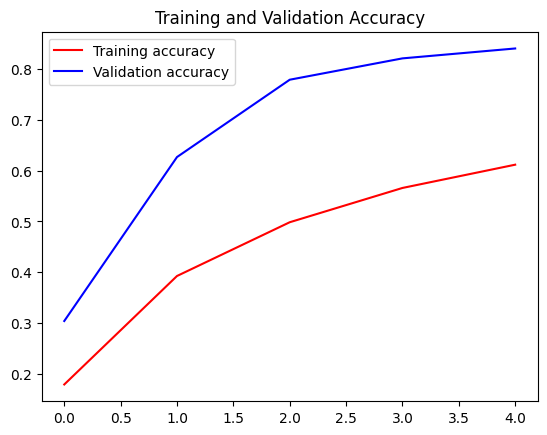

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.figure()

<Figure size 640x480 with 0 Axes>

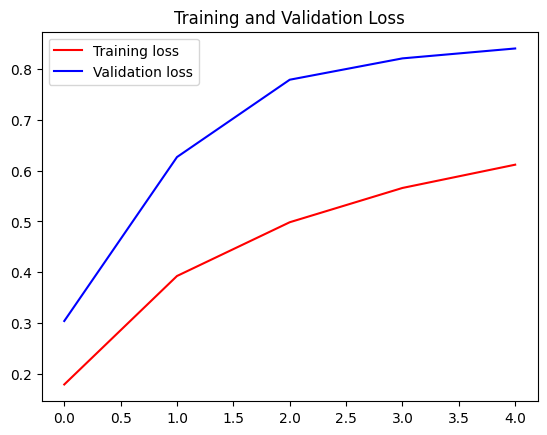

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(epochs, acc, 'r', label='Training loss')
plt.plot(epochs, val_acc, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.figure()

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 527ms/step


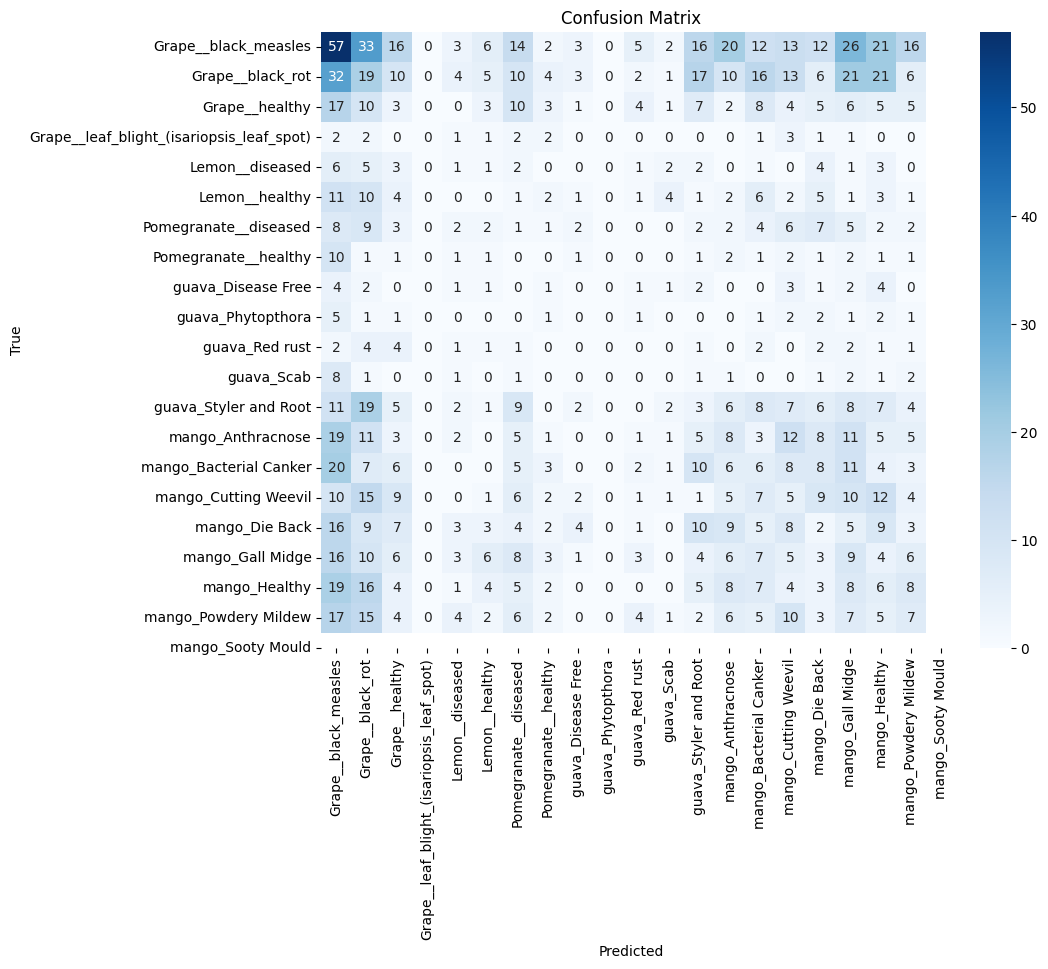

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

test_generator.reset()
predictions = model.predict(test_generator, steps=len(test_generator), verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
label_map

{'Grape__black_measles': 0,
 'Grape__black_rot': 1,
 'Grape__healthy': 2,
 'Grape__leaf_blight_(isariopsis_leaf_spot)': 3,
 'Lemon__diseased': 4,
 'Lemon__healthy': 5,
 'Pomegranate__diseased': 6,
 'Pomegranate__healthy': 7,
 'guava_Disease Free': 8,
 'guava_Phytopthora': 9,
 'guava_Red rust': 10,
 'guava_Scab': 11,
 'guava_Styler and Root': 12,
 'mango_Anthracnose': 13,
 'mango_Bacterial Canker': 14,
 'mango_Cutting Weevil': 15,
 'mango_Die Back': 16,
 'mango_Gall Midge': 17,
 'mango_Healthy': 18,
 'mango_Powdery Mildew': 19,
 'mango_Sooty Mould': 20}

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_26']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


52/52 ━━━━━━━━━━━━━━━━━━━━ 33s 604ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


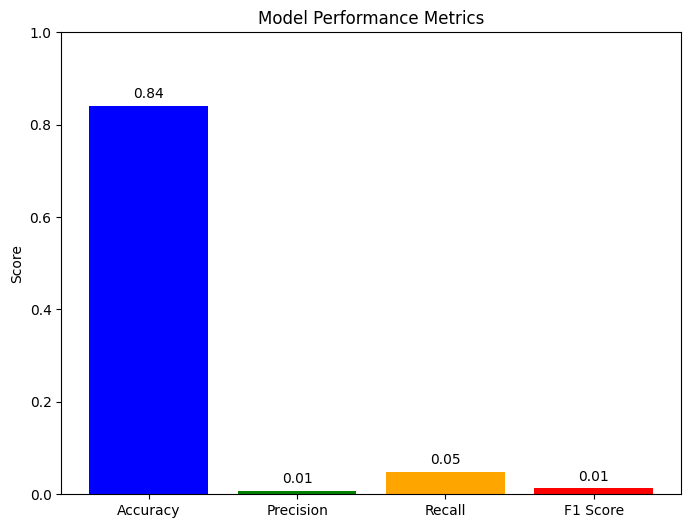

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
test_generator.reset()  # Reset generator to start
y_pred = model.predict(test_generator, steps=len(test_generator), verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

f1 = f1_score(y_true, y_pred_classes, average='weighted')
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [test_acc, precision, recall, f1]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')
plt.show()